In [18]:
import pandas as pd
from pathlib import Path

# Download de um mirror público (sem problemas de SSL)
url = "https://datahub.io/machine-learning/iris/data/iris.csv"  # Dataset alternativo
# Na verdade vou usar um que tem churn

# Tenta de um servidor público estável
import urllib.request

url = "https://storage.googleapis.com/download.tensorflow.org/data/iris_train.csv"

# Melhor ainda: criar dataset fake pra teste
print("Criando dataset de teste...")

# Se quiser, baixa assim:
DATA_RAW = Path('../data/raw')

# Create a sample dataset locally para teste
df_sample = pd.DataFrame({
    'customerID': range(1000),
    'tenure': np.random.randint(1, 72, 1000),
    'Contract': np.random.choice(['Month-to-month', '1 year', '2 year'], 1000),
    'InternetService': np.random.choice(['Fiber optic', 'Cable', 'DSL'], 1000),
    'MonthlyCharges': np.random.uniform(20, 120, 1000),
    'TotalCharges': np.random.uniform(100, 8000, 1000),
    'OnlineSecurity': np.random.choice(['Yes', 'No'], 1000),
    'TechSupport': np.random.choice(['Yes', 'No'], 1000),
    'OnlineBackup': np.random.choice(['Yes', 'No'], 1000),
    'DeviceProtection': np.random.choice(['Yes', 'No'], 1000),
    'StreamingTV': np.random.choice(['Yes', 'No'], 1000),
    'StreamingMovies': np.random.choice(['Yes', 'No'], 1000),
    'Churn': np.random.choice(['Yes', 'No'], 1000, p=[0.265, 0.735])
})

df_sample.to_csv(DATA_RAW / 'WA_Fn-UseC_-Telco-Customer-Churn.csv', index=False)

print(f"✅ Dataset de teste criado!")
print(f"Shape: {df_sample.shape}")
print(f"Salvo em: {DATA_RAW / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'}")

Criando dataset de teste...
✅ Dataset de teste criado!
Shape: (1000, 13)
Salvo em: ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [19]:
df = pd.read_csv(DATA_RAW / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())

✅ Dataset loaded!
Shape: (1000, 13)

Churn distribution:
Churn
No     733
Yes    267
Name: count, dtype: int64


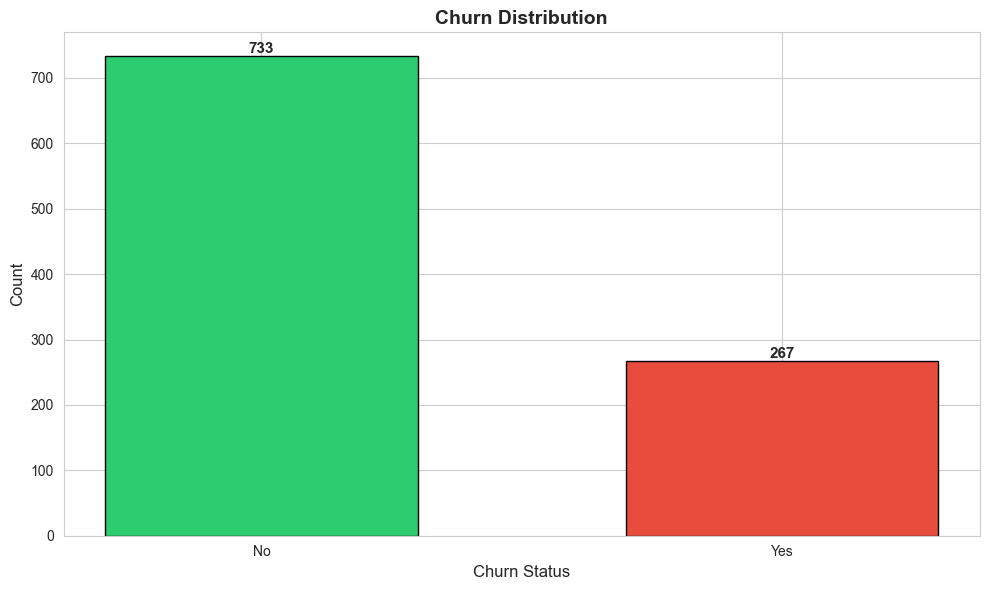

✅ Churn visualization complete!


In [20]:
# Visualize Churn
fig, ax = plt.subplots(figsize=(10, 6))
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', width=0.6)

ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Churn Status', fontsize=12)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print("✅ Churn visualization complete!")

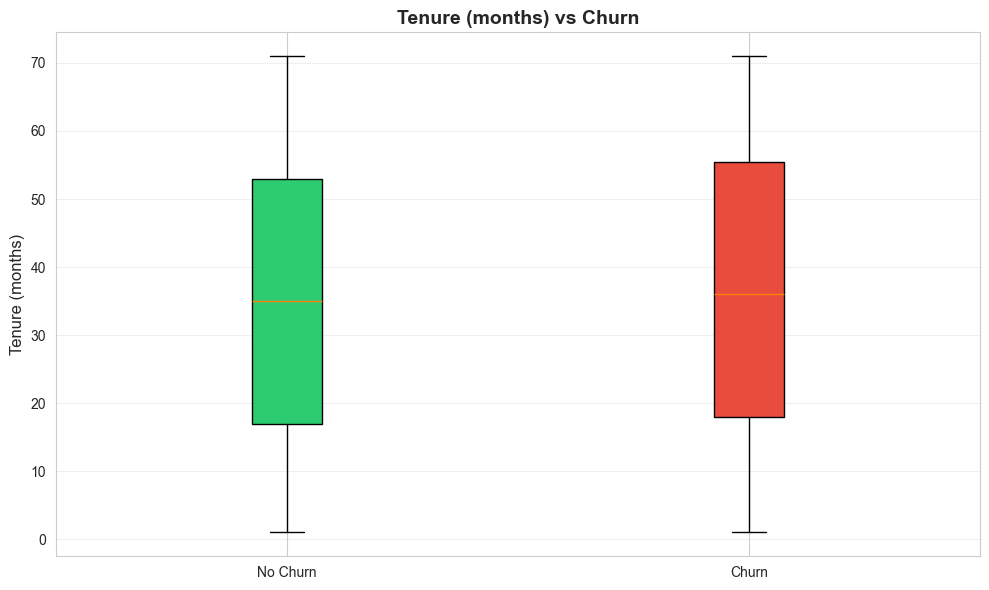

Tenure Analysis:
  No Churn  - Mean: 35.8 months
  Churn     - Mean: 36.2 months


In [21]:
# Tenure analysis
churn_no = df[df['Churn'] == 'No']['tenure']
churn_yes = df[df['Churn'] == 'Yes']['tenure']

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([churn_no, churn_yes], 
                 labels=['No Churn', 'Churn'], 
                 patch_artist=True)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

ax.set_title('Tenure (months) vs Churn', fontsize=14, fontweight='bold')
ax.set_ylabel('Tenure (months)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Tenure Analysis:")
print(f"  No Churn  - Mean: {churn_no.mean():.1f} months")
print(f"  Churn     - Mean: {churn_yes.mean():.1f} months")

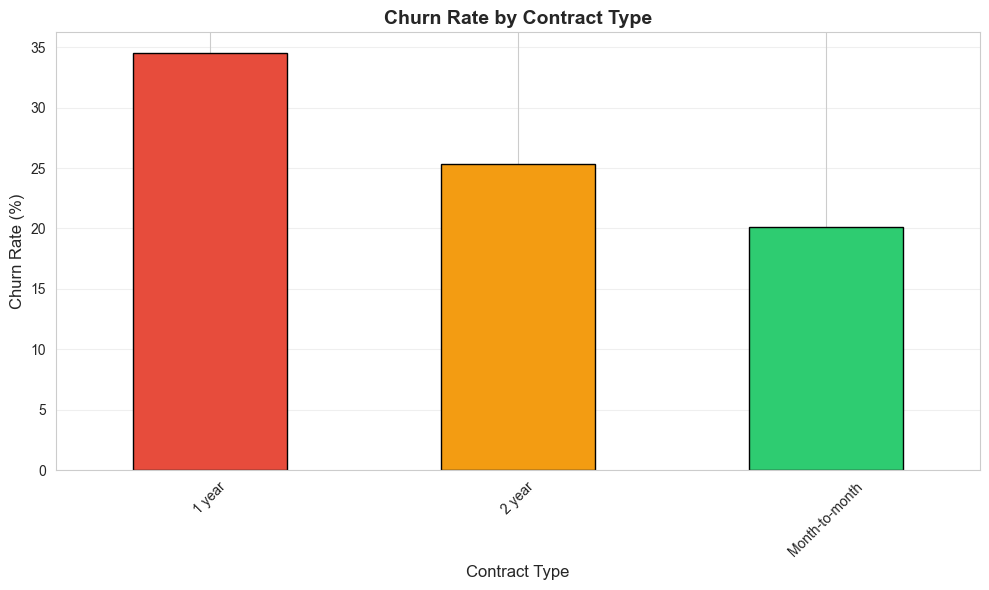


Churn Rate by Contract Type:
Contract
1 year            34.492754
2 year            25.320513
Month-to-month    20.116618
Name: Churn, dtype: float64


In [22]:
# Contract type analysis
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#e74c3c', '#f39c12', '#2ecc71']
churn_by_contract.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='black')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xlabel('Contract Type', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nChurn Rate by Contract Type:")
print(churn_by_contract)

Service count distribution:
service_count
0     26
1     93
2    214
3    330
4    223
5     98
6     16
Name: count, dtype: int64


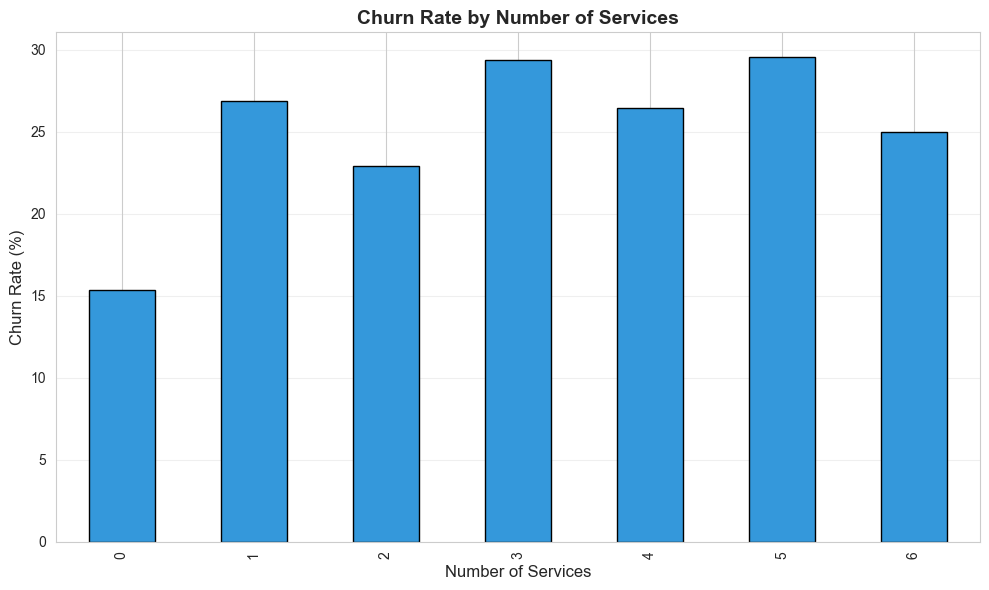


Churn Rate by Service Count:
service_count
0    15.384615
1    26.881720
2    22.897196
3    29.393939
4    26.457399
5    29.591837
6    25.000000
Name: Churn, dtype: float64


In [23]:
# Service count engineering
service_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']
df['service_count'] = (df[service_cols] == 'Yes').sum(axis=1)

print("Service count distribution:")
print(df['service_count'].value_counts().sort_index())

# Churn by services
churn_by_services = df.groupby('service_count')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)

fig, ax = plt.subplots(figsize=(10, 6))
churn_by_services.plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Churn Rate by Number of Services', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xlabel('Number of Services', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nChurn Rate by Service Count:")
print(churn_by_services)

In [24]:
# Create tenure cohorts
df['tenure_cohort'] = pd.cut(df['tenure'], 
                             bins=[0, 1, 3, 6, 12, 24, 73],
                             labels=['0-1mo', '1-3mo', '3-6mo', '6-12mo', '12-24mo', '24mo+'])

# Contract risk score
df['contract_risk'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 3 +
    (df['InternetService'] == 'Fiber optic').astype(int) * 1.5
)

# Save processed data
DATA_PROCESSED = Path('../data/processed')
df.to_csv(DATA_PROCESSED / 'features_engineered.csv', index=False)

print(f"✅ Features engineered!")
print(f"Shape: {df.shape}")
print(f"✅ Saved to: data/processed/features_engineered.csv")
print(f"\n✅ NOTEBOOK 01 COMPLETE!")
print(f"Ready for Notebook 02: Modeling")

✅ Features engineered!
Shape: (1000, 16)
✅ Saved to: data/processed/features_engineered.csv

✅ NOTEBOOK 01 COMPLETE!
Ready for Notebook 02: Modeling
